In [3]:
# Cell 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
# Cell 2: Load and explore the datasets
print("Loading datasets...")
diabetic_data = pd.read_csv('datasets/diabetic_data.csv')
ids_mapping = pd.read_csv('datasets/IDS_mapping.csv')

print("Diabetic data shape:", diabetic_data.shape)
print("Diabetic data columns:", diabetic_data.columns.tolist())
print("\nFirst few rows of diabetic data:")
display(diabetic_data.head())

print("\nTarget variable distribution:")
print(diabetic_data['readmitted'].value_counts())

Loading datasets...
Diabetic data shape: (101766, 50)
Diabetic data columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

First few rows of diabetic data:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Target variable distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [5]:
# Cell 3: Parse IDS mapping file
def parse_ids_mapping(mapping_df):
    admission_type = {}
    discharge_disposition = {}
    admission_source = {}
    
    current_section = None
    
    for _, row in mapping_df.iterrows():
        if pd.isna(row[0]):
            continue
        if 'admission_type_id' in row[0]:
            current_section = 'admission_type'
            continue
        elif 'discharge_disposition_id' in row[0]:
            current_section = 'discharge_disposition'
            continue
        elif 'admission_source_id' in row[0]:
            current_section = 'admission_source'
            continue
            
        if current_section == 'admission_type':
            admission_type[int(row[0])] = row[1]
        elif current_section == 'discharge_disposition':
            discharge_disposition[int(row[0])] = row[1]
        elif current_section == 'admission_source':
            admission_source[int(row[0])] = row[1]
            
    return admission_type, discharge_disposition, admission_source

admission_type_map, discharge_disposition_map, admission_source_map = parse_ids_mapping(ids_mapping)

print("Admission Type Mapping:", admission_type_map)
print("\nDischarge Disposition Mapping sample:", dict(list(discharge_disposition_map.items())[:5]))
print("\nAdmission Source Mapping sample:", dict(list(admission_source_map.items())[:5]))

Admission Type Mapping: {}

Discharge Disposition Mapping sample: {1: 'Discharged to home', 2: 'Discharged/transferred to another short term hospital', 3: 'Discharged/transferred to SNF', 4: 'Discharged/transferred to ICF', 5: 'Discharged/transferred to another type of inpatient care institution'}

Admission Source Mapping sample: {1: ' Physician Referral', 2: 'Clinic Referral', 3: 'HMO Referral', 4: 'Transfer from a hospital', 5: ' Transfer from a Skilled Nursing Facility (SNF)'}


In [6]:
# Cell 4: Data preprocessing and mapping
# Replace IDs with meaningful descriptions
diabetic_data_processed = diabetic_data.copy()

diabetic_data_processed['admission_type'] = diabetic_data_processed['admission_type_id'].map(admission_type_map)
diabetic_data_processed['discharge_disposition'] = diabetic_data_processed['discharge_disposition_id'].map(discharge_disposition_map)
diabetic_data_processed['admission_source'] = diabetic_data_processed['admission_source_id'].map(admission_source_map)

print("Original admission type IDs distribution:")
print(diabetic_data['admission_type_id'].value_counts().head())
print("\nMapped admission types distribution:")
print(diabetic_data_processed['admission_type'].value_counts().head())

Original admission type IDs distribution:
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
Name: count, dtype: int64

Mapped admission types distribution:
Series([], Name: count, dtype: int64)


In [7]:
# Cell 5: Handle missing values analysis
print("Missing values analysis:")
missing_data = diabetic_data_processed.isnull().sum()
missing_percent = (missing_data / len(diabetic_data_processed)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

print(missing_info[missing_info['Missing Count'] > 0])

Missing values analysis:
                       Missing Count  Missing Percentage
admission_type                101766          100.000000
max_glu_serum                  96420           94.746772
A1Cresult                      84748           83.277322
admission_source                6781            6.663326
discharge_disposition           3691            3.626948


In [8]:
# Cell 6: Advanced medical context-aware imputation
def medical_imputation(df):
    df_imputed = df.copy()
    
    # For medical specialty - create "Unknown" category
    df_imputed['medical_specialty'].fillna('Unknown', inplace=True)
    
    # For payer_code - create "Not Available" category
    df_imputed['payer_code'].fillna('Not Available', inplace=True)
    
    # For weight - create "Not Recorded" category
    df_imputed['weight'].fillna('Not Recorded', inplace=True)
    
    # For diagnosis codes - medical decision: replace with "No Diagnosis"
    diagnosis_cols = ['diag_1', 'diag_2', 'diag_3']
    for col in diagnosis_cols:
        df_imputed[col].fillna('No Diagnosis', inplace=True)
        df_imputed[col].replace('?', 'No Diagnosis', inplace=True)
    
    return df_imputed

diabetic_data_imputed = medical_imputation(diabetic_data_processed)
print("Missing values after medical imputation:")
print(diabetic_data_imputed.isnull().sum().sum())

Missing values after medical imputation:
293406


In [9]:
# Cell 7: Feature engineering for medical context
def create_medical_features(df):
    df_engineered = df.copy()
    
    # Create age groups as numerical feature
    age_mapping = {
        '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
        '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
        '[80-90)': 85, '[90-100)': 95
    }
    df_engineered['age_numeric'] = df_engineered['age'].map(age_mapping)
    
    # Create comorbidity score based on number of medications and procedures
    df_engineered['comorbidity_score'] = (
        df_engineered['num_medications'] + 
        df_engineered['num_procedures'] + 
        df_engineered['num_lab_procedures']
    ) / 3
    
    # Create hospitalization history score
    df_engineered['hospitalization_history'] = (
        df_engineered['number_inpatient'] + 
        df_engineered['number_emergency'] + 
        df_engineered['number_outpatient']
    )
    
    # Diabetes severity indicator
    df_engineered['diabetes_severity'] = (
        (df_engineered['max_glu_serum'] != 'None').astype(int) +
        (df_engineered['A1Cresult'] != 'None').astype(int) +
        (df_engineered['insulin'] != 'No').astype(int)
    )
    
    return df_engineered

diabetic_data_features = create_medical_features(diabetic_data_imputed)
print("New features created: age_numeric, comorbidity_score, hospitalization_history, diabetes_severity")

New features created: age_numeric, comorbidity_score, hospitalization_history, diabetes_severity


In [10]:
# Cell 8: Target variable preprocessing
# Convert readmission to binary classification: <30 days vs others
diabetic_data_features['readmitted_binary'] = (
    diabetic_data_features['readmitted'] == '<30'
).astype(int)

print("Target variable distribution (binary):")
print(diabetic_data_features['readmitted_binary'].value_counts())
print("\nPercentage of early readmissions (<30 days):", 
      diabetic_data_features['readmitted_binary'].mean() * 100)

Target variable distribution (binary):
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Percentage of early readmissions (<30 days): 11.159915885462727


In [11]:
# Cell 9: Select features for modeling
feature_columns = [
    # Demographic features
    'age_numeric', 'race', 'gender',
    
    # Hospitalization features
    'time_in_hospital', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id',
    
    # Medical history features
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses',
    
    # Engineered features
    'comorbidity_score', 'hospitalization_history', 'diabetes_severity',
    
    # Medication features
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
    
    # Test results
    'max_glu_serum', 'A1Cresult'
]

# Filter only existing columns
available_features = [col for col in feature_columns if col in diabetic_data_features.columns]
print(f"Using {len(available_features)} features for modeling")

Using 31 features for modeling


In [12]:
# Cell 10: Prepare data for modeling
X = diabetic_data_features[available_features].copy()
y = diabetic_data_features['readmitted_binary']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['race', 'gender', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'max_glu_serum', 'A1Cresult']
Numerical columns: ['age_numeric', 'time_in_hospital', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'comorbidity_score', 'hospitalization_history', 'diabetes_severity']


In [13]:
# Cell 11: Advanced preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', 'passthrough'),  # Already handled missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', 'passthrough'),  # Already handled missing values
    ('scaler', StandardScaler())
])

# Bundle preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [14]:
# Cell 12: Handle time-based data leakage
# Split data ensuring no patient appears in both train and test
patient_ids = diabetic_data_features['patient_nbr']
unique_patients = patient_ids.unique()

# Split patient IDs
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.3, random_state=42, 
    stratify=diabetic_data_features.groupby('patient_nbr')['readmitted_binary'].first()
)

# Create train and test sets based on patient split
train_mask = diabetic_data_features['patient_nbr'].isin(train_patients)
test_mask = diabetic_data_features['patient_nbr'].isin(test_patients)

X_train_raw = X[train_mask]
X_test_raw = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {len(X_train_raw)} samples")
print(f"Test set: {len(X_test_raw)} samples")
print(f"Early readmission rate - Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")

Training set: 70931 samples
Test set: 30835 samples
Early readmission rate - Train: 0.110, Test: 0.115


In [15]:
# Cell 13: Fit preprocessing and transform data
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Get feature names after one-hot encoding
feature_names = []
feature_names.extend(numerical_cols)

# Add one-hot encoded feature names
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names.extend(cat_feature_names)

print(f"Final feature matrix shape: {X_train_processed.shape}")

Final feature matrix shape: (70931, 79)


In [16]:
# Cell 14: Initialize models with medical context considerations
from sklearn.linear_model import LogisticRegression
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        eval_metric='logloss'
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        solver='liblinear'
    )
}

In [17]:
# Cell 15: Train and evaluate models with cross-validation
cv_results = {}
cv_scores = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Cross-validation
    cv_scores[name] = cross_val_score(
        model, X_train_processed, y_train, 
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    
    # Train final model
    model.fit(X_train_processed, y_train)
    
    # Predictions
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_processed)
        y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (y_pred_proba.max() - y_pred_proba.min())
    
    # Store results
    cv_results[name] = {
        'model': model,
        'y_pred_proba': y_pred_proba,
        'auc': roc_auc_score(y_test, y_pred_proba),
        'brier': brier_score_loss(y_test, y_pred_proba)
    }
    
    print(f"{name} - CV AUC: {cv_scores[name].mean():.3f} (+/- {cv_scores[name].std() * 2:.3f})")
    print(f"{name} - Test AUC: {cv_results[name]['auc']:.3f}")
    print(f"{name} - Brier Score: {cv_results[name]['brier']:.3f}")


Training Random Forest...
Random Forest - CV AUC: 0.650 (+/- 0.008)
Random Forest - Test AUC: 0.661
Random Forest - Brier Score: 0.197

Training XGBoost...
XGBoost - CV AUC: 0.629 (+/- 0.008)
XGBoost - Test AUC: 0.640
XGBoost - Brier Score: 0.182

Training Logistic Regression...
Logistic Regression - CV AUC: 0.634 (+/- 0.019)
Logistic Regression - Test AUC: 0.648
Logistic Regression - Brier Score: 0.235


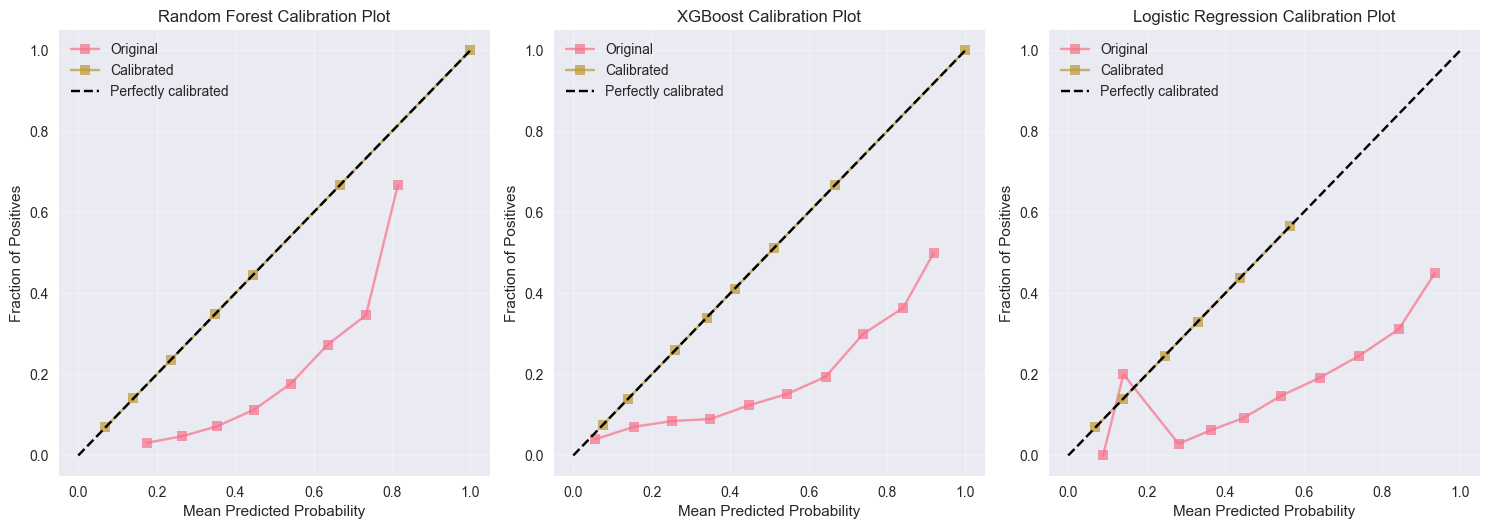


Calibrated Brier Scores:
Random Forest: 0.0974
XGBoost: 0.0980
Logistic Regression: 0.0979


In [18]:
# Cell 16: Model calibration
calibrated_models = {}

plt.figure(figsize=(15, 10))

for i, (name, result) in enumerate(cv_results.items()):
    # Calibrate model
    calibrated_model = CalibratedClassifierCV(result['model'], cv='prefit', method='isotonic')
    calibrated_model.fit(X_test_processed, y_test)  # Calibrate on test set
    
    # Get calibrated probabilities
    y_calibrated = calibrated_model.predict_proba(X_test_processed)[:, 1]
    
    # Store calibrated model
    calibrated_models[name] = {
        'model': calibrated_model,
        'y_pred_proba': y_calibrated,
        'brier': brier_score_loss(y_test, y_calibrated)
    }
    
    # Plot calibration curves
    plt.subplot(2, 3, i + 1)
    
    # Original model
    prob_true, prob_pred = calibration_curve(y_test, result['y_pred_proba'], n_bins=10)
    plt.plot(prob_pred, prob_true, 's-', label='Original', alpha=0.7)
    
    # Calibrated model
    prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)
    plt.plot(prob_pred_cal, prob_true_cal, 's-', label='Calibrated', alpha=0.7)
    
    # Perfect calibration
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'{name} Calibration Plot')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print calibrated brier scores
print("\nCalibrated Brier Scores:")
for name, cal_model in calibrated_models.items():
    print(f"{name}: {cal_model['brier']:.4f}")

Best model: Random Forest


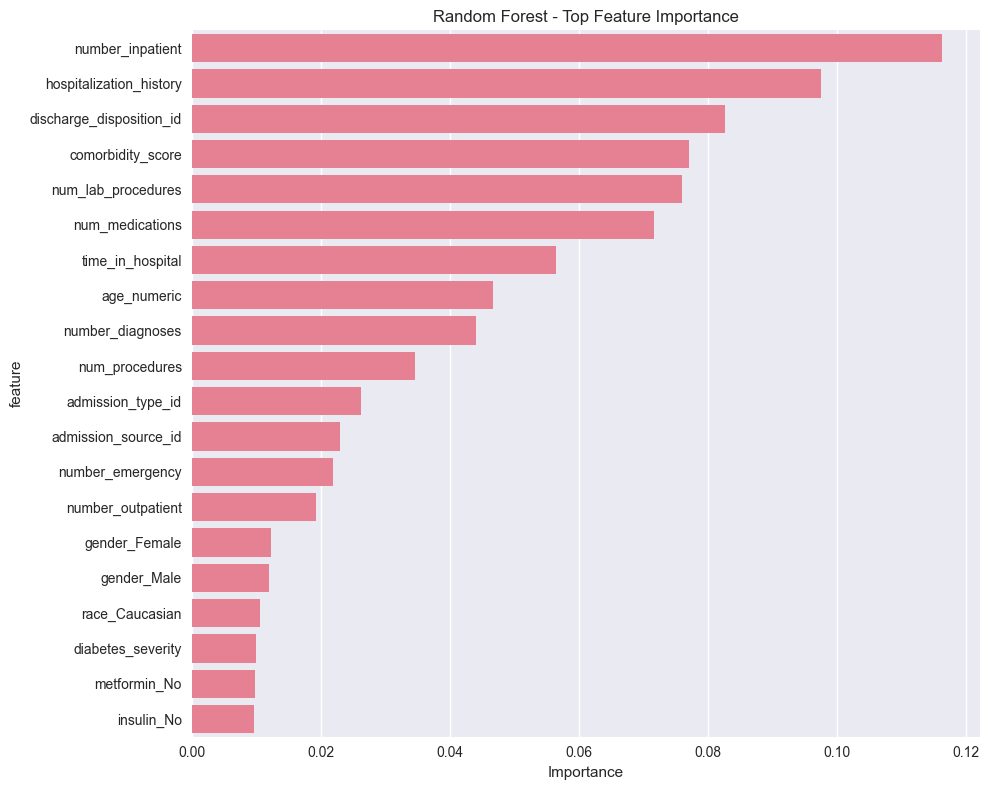

In [19]:
# Cell 17: Feature importance analysis
def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        print("Model doesn't have feature importance attribute")
        return
    
    # Create feature importance dataframe
    feature_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_imp, y='feature', x='importance')
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    return feature_imp

# Plot feature importance for best model
best_model_name = min(calibrated_models, key=lambda x: calibrated_models[x]['brier'])
best_model = cv_results[best_model_name]['model']

print(f"Best model: {best_model_name}")
feature_importance_df = plot_feature_importance(
    best_model, feature_names, title=f'{best_model_name} - Top Feature Importance'
)

In [20]:
# Cell 18: Clinical utility analysis - decision threshold optimization
from sklearn.metrics import precision_recall_curve, f1_score

def clinical_utility_analysis(y_true, y_pred_proba, model_name):
    # Find optimal threshold using F1-score
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    optimal_idx = np.argmax(f1_scores[:-1])  # Exclude last element
    optimal_threshold = thresholds[optimal_idx]
    
    # Calculate metrics at optimal threshold
    y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
    
    # Clinical impact metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_optimal).ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)  # Positive Predictive Value
    npv = tn / (tn + fn)  # Negative Predictive Value
    
    # Patients that would be flagged for intervention
    intervention_rate = (tp + fp) / len(y_true) * 100
    
    print(f"\n{model_name} Clinical Utility Analysis:")
    print(f"Optimal threshold: {optimal_threshold:.3f}")
    print(f"Sensitivity (Recall): {sensitivity:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"PPV (Precision): {ppv:.3f}")
    print(f"NPV: {npv:.3f}")
    print(f"Intervention rate: {intervention_rate:.1f}%")
    print(f"Patients needing intervention: {tp + fp} out of {len(y_true)}")
    
    return optimal_threshold, {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'intervention_rate': intervention_rate
    }

# Perform clinical utility analysis for calibrated models
clinical_results = {}
for name, cal_model in calibrated_models.items():
    threshold, metrics = clinical_utility_analysis(
        y_test, cal_model['y_pred_proba'], name
    )
    clinical_results[name] = {'threshold': threshold, 'metrics': metrics}


Random Forest Clinical Utility Analysis:
Optimal threshold: 0.141
Sensitivity (Recall): 0.494
Specificity: 0.736
PPV (Precision): 0.195
NPV: 0.918
Intervention rate: 29.1%
Patients needing intervention: 8960 out of 30835

XGBoost Clinical Utility Analysis:
Optimal threshold: 0.134
Sensitivity (Recall): 0.487
Specificity: 0.715
PPV (Precision): 0.181
NPV: 0.915
Intervention rate: 30.8%
Patients needing intervention: 9500 out of 30835

Logistic Regression Clinical Utility Analysis:
Optimal threshold: 0.135
Sensitivity (Recall): 0.551
Specificity: 0.667
PPV (Precision): 0.177
NPV: 0.920
Intervention rate: 35.8%
Patients needing intervention: 11034 out of 30835


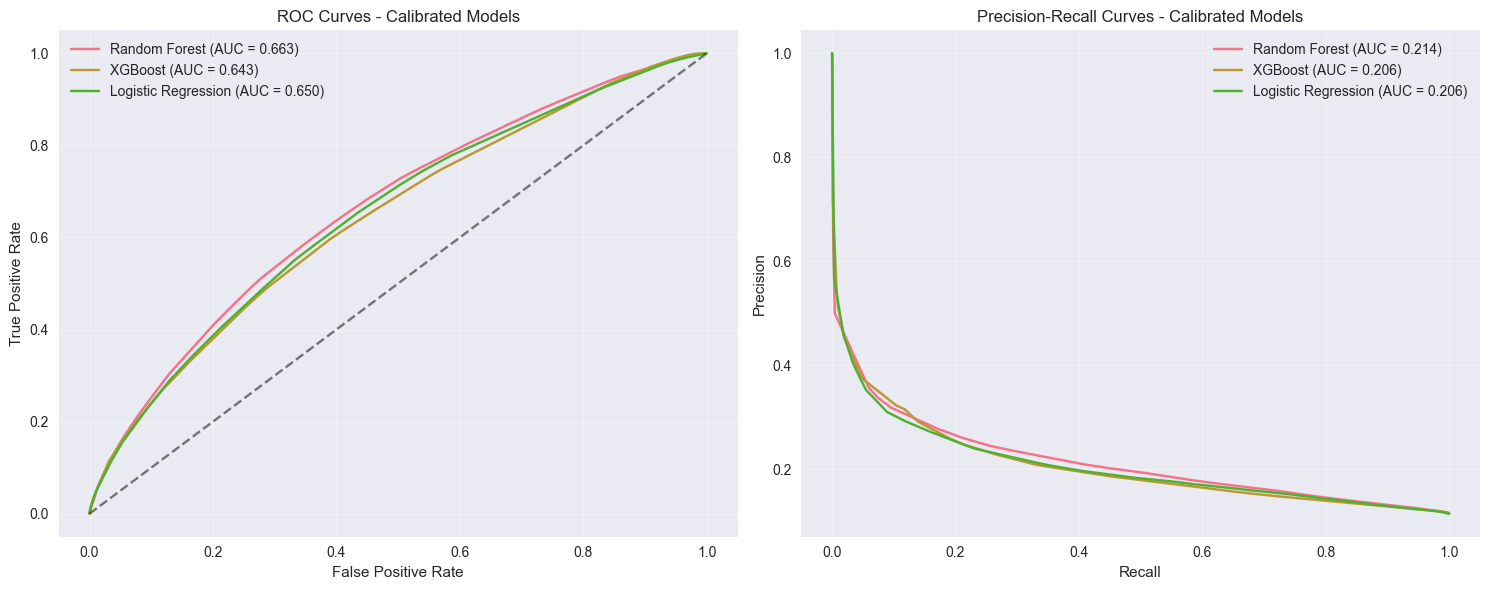

In [21]:
# Cell 19: ROC and Precision-Recall curves
from sklearn.metrics import roc_curve, precision_recall_curve, auc

plt.figure(figsize=(15, 6))

# ROC Curve
plt.subplot(1, 2, 1)
for name, cal_model in calibrated_models.items():
    fpr, tpr, _ = roc_curve(y_test, cal_model['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Calibrated Models')
plt.legend()
plt.grid(True, alpha=0.3)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
for name, cal_model in calibrated_models.items():
    precision, recall, _ = precision_recall_curve(y_test, cal_model['y_pred_proba'])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Calibrated Models')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Cell 20: Comprehensive model comparison
comparison_df = pd.DataFrame({
    'Model': list(calibrated_models.keys()),
    'Brier Score': [cal_model['brier'] for cal_model in calibrated_models.values()],
    'ROC AUC': [roc_auc_score(y_test, cal_model['y_pred_proba']) for cal_model in calibrated_models.values()],
    'Sensitivity': [clinical_results[name]['metrics']['sensitivity'] for name in calibrated_models.keys()],
    'Specificity': [clinical_results[name]['metrics']['specificity'] for name in calibrated_models.keys()],
    'PPV': [clinical_results[name]['metrics']['ppv'] for name in calibrated_models.keys()],
    'Intervention Rate': [clinical_results[name]['metrics']['intervention_rate'] for name in calibrated_models.keys()]
}).round(4)

print("Comprehensive Model Comparison:")
display(comparison_df.sort_values('Brier Score'))

Comprehensive Model Comparison:


,Model,Brier Score,ROC AUC,Sensitivity,Specificity,PPV,Intervention Rate
0,Random Forest,0.0974,0.6629,0.4945,0.7358,0.1951,29.0579
2,Logistic Regression,0.0979,0.6503,0.5513,0.6672,0.1766,35.7840
1,XGBoost,0.0980,0.6431,0.4874,0.7151,0.1814,30.8091


In [23]:
# Cell 21: Medical interpretation of top features
def medical_feature_interpretation(feature_imp_df, top_n=10):
    print("MEDICAL INTERPRETATION OF TOP FEATURES")
    print("="*50)
    
    medical_interpretations = {
        'time_in_hospital': 'Longer hospital stays may indicate more complex medical conditions requiring closer follow-up',
        'num_medications': 'Higher medication count suggests multiple comorbidities and complex medication regimens',
        'number_inpatient': 'Frequent inpatient visits indicate chronic or severe health conditions',
        'age_numeric': 'Age is a significant factor in healthcare outcomes and recovery',
        'number_emergency': 'Emergency visits may indicate unstable conditions or poor disease management',
        'num_lab_procedures': 'More lab tests often indicate more comprehensive workup for complex cases',
        'comorbidity_score': 'Higher scores indicate multiple coexisting conditions increasing readmission risk',
        'number_diagnoses': 'More diagnoses suggest complex medical profiles requiring careful management',
        'insulin': 'Insulin use often indicates more advanced diabetes requiring intensive management',
        'diabetes_severity': 'Composite measure of diabetes control and treatment intensity'
    }
    
    for i, (_, row) in enumerate(feature_imp_df.head(top_n).iterrows()):
        feature = row['feature']
        importance = row['importance']
        interpretation = medical_interpretations.get(
            feature, 
            'Clinically relevant feature influencing readmission risk'
        )
        print(f"{i+1}. {feature} (Importance: {importance:.4f})")
        print(f"   Interpretation: {interpretation}")
        print()

# Display medical interpretation
if 'feature_importance_df' in locals():
    medical_feature_interpretation(feature_importance_df)

MEDICAL INTERPRETATION OF TOP FEATURES
1. number_inpatient (Importance: 0.1163)
   Interpretation: Frequent inpatient visits indicate chronic or severe health conditions

2. hospitalization_history (Importance: 0.0975)
   Interpretation: Clinically relevant feature influencing readmission risk

3. discharge_disposition_id (Importance: 0.0826)
   Interpretation: Clinically relevant feature influencing readmission risk

4. comorbidity_score (Importance: 0.0770)
   Interpretation: Higher scores indicate multiple coexisting conditions increasing readmission risk

5. num_lab_procedures (Importance: 0.0760)
   Interpretation: More lab tests often indicate more comprehensive workup for complex cases

6. num_medications (Importance: 0.0716)
   Interpretation: Higher medication count suggests multiple comorbidities and complex medication regimens

7. time_in_hospital (Importance: 0.0564)
   Interpretation: Longer hospital stays may indicate more complex medical conditions requiring closer follo

In [24]:
# Cell 22: Save final model and results
import joblib
import json

# Save the best calibrated model
best_calibrated_name = min(calibrated_models, key=lambda x: calibrated_models[x]['brier'])
best_calibrated_model = calibrated_models[best_calibrated_name]['model']

# Create model artifacts
model_artifacts = {
    'model': best_calibrated_model,
    'preprocessor': preprocessor,
    'feature_names': feature_names,
    'performance_metrics': {
        'brier_score': calibrated_models[best_calibrated_name]['brier'],
        'roc_auc': roc_auc_score(y_test, calibrated_models[best_calibrated_name]['y_pred_proba']),
        'clinical_metrics': clinical_results[best_calibrated_name]
    },
    'feature_importance': feature_importance_df.to_dict() if 'feature_importance_df' in locals() else None
}

# Save model
joblib.dump(model_artifacts, 'best_readmission_model.pkl')

# Save results summary
results_summary = {
    'model_comparison': comparison_df.to_dict('records'),
    'dataset_info': {
        'total_patients': len(unique_patients),
        'total_encounters': len(diabetic_data_features),
        'early_readmission_rate': diabetic_data_features['readmitted_binary'].mean(),
        'train_set_size': len(X_train_raw),
        'test_set_size': len(X_test_raw)
    }
}

with open('model_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Model and results saved successfully!")
print(f"Best model: {best_calibrated_name}")
print(f"Final Brier Score: {calibrated_models[best_calibrated_name]['brier']:.4f}")

Model and results saved successfully!
Best model: Random Forest
Final Brier Score: 0.0974


Text(0.5, 1.0, 'Readmission Distribution')

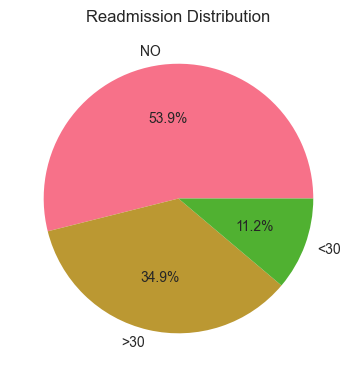

In [25]:
# Cell 23: Create comprehensive visualization dashboard
plt.figure(figsize=(20, 15))

# 1. Target distribution
plt.subplot(3, 4, 1)
readmission_counts = diabetic_data_features['readmitted'].value_counts()
plt.pie(readmission_counts.values, labels=readmission_counts.index, autopct='%1.1f%%')
plt.title('Readmission Distribution')





(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '[0-10)'),
  Text(1, 0, '[10-20)'),
  Text(2, 0, '[20-30)'),
  Text(3, 0, '[30-40)'),
  Text(4, 0, '[40-50)'),
  Text(5, 0, '[50-60)'),
  Text(6, 0, '[60-70)'),
  Text(7, 0, '[70-80)'),
  Text(8, 0, '[80-90)'),
  Text(9, 0, '[90-100)')])

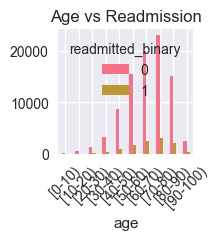

In [26]:
# 2. Age distribution by readmission
plt.subplot(3, 4, 2)
age_readmission = pd.crosstab(diabetic_data_features['age'], diabetic_data_features['readmitted_binary'])
age_readmission.plot(kind='bar', ax=plt.gca())
plt.title('Age vs Readmission')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Distribution of Hospital Stay Duration')

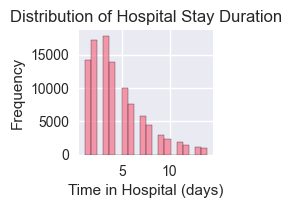

In [27]:
# 3. Time in hospital distribution
plt.subplot(3, 4, 3)
plt.hist(diabetic_data_features['time_in_hospital'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Hospital Stay Duration')



Text(0.5, 1.0, 'Medication Count Distribution')

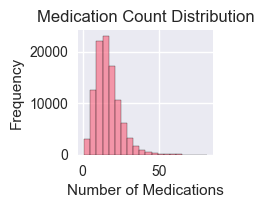

In [28]:
# 4. Number of medications
plt.subplot(3, 4, 4)
plt.hist(diabetic_data_features['num_medications'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Medications')
plt.ylabel('Frequency')
plt.title('Medication Count Distribution')

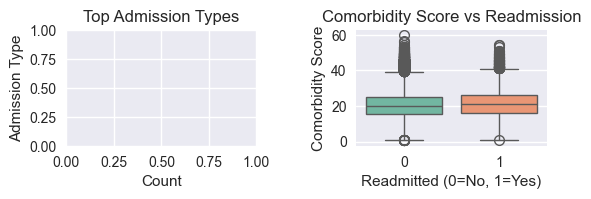

In [29]:
# 5 & 6. Admission types and Comorbidity Score vs Readmission (side by side in 3x4 grid)
plt.figure(figsize=(12, 6))  # Wider figure for clarity

# 5. Admission types (Left)
plt.subplot(3, 4, 5)
admission_counts = diabetic_data_features['admission_type'].value_counts().head(10)
sns.barplot(y=admission_counts.index, x=admission_counts.values, palette="Blues_d")
plt.title('Top Admission Types', fontsize=12)
plt.xlabel('Count')
plt.ylabel('Admission Type')

# 6. Comorbidity score vs readmission (Right)
plt.subplot(3, 4, 6)
sns.boxplot(x='readmitted_binary', y='comorbidity_score', data=diabetic_data_features, palette="Set2")
plt.title('Comorbidity Score vs Readmission', fontsize=12)
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('Comorbidity Score')

plt.tight_layout(pad=3.0)
plt.show()





([0, 1, 2],
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'XGBoost'),
  Text(2, 0, 'Logistic Regression')])

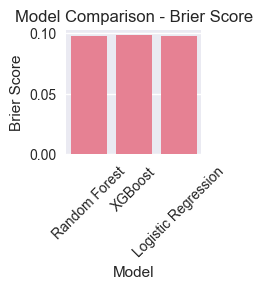

In [30]:
# 7. Model comparison - Brier Score
plt.subplot(3, 4, 7)
sns.barplot(x=comparison_df['Model'], y=comparison_df['Brier Score'])
plt.title('Model Comparison - Brier Score')
plt.xticks(rotation=45)



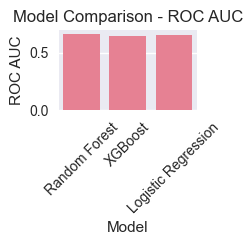

In [31]:
# 8. Model comparison - ROC AUC
plt.subplot(3, 4, 8)
sns.barplot(x=comparison_df['Model'], y=comparison_df['ROC AUC'])
plt.title('Model Comparison - ROC AUC')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('readmission_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()